# Exploratory Data Analysis & Feature Engineering
**Goal**: Explore the healthcare dataset, clean it, engineer features, and save `processed_data.csv` for model training.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, shutil, warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Ensure raw data is in data/ folder
RAW_CSV = 'healthcare_synthetic_data.csv'
DATA_CSV = os.path.join('..', 'data', RAW_CSV) if os.path.basename(os.getcwd()) == 'data' else RAW_CSV

# Try loading from data/ first, fall back to project root
if os.path.exists(RAW_CSV):
    df = pd.read_csv(RAW_CSV)
elif os.path.exists(os.path.join('..', RAW_CSV)):
    df = pd.read_csv(os.path.join('..', RAW_CSV))
else:
    raise FileNotFoundError('Cannot find healthcare_synthetic_data.csv')

print(f'Loaded: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

Loaded: 15000 rows × 19 columns


,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
0,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
1,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
2,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
3,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
4,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0


## 1. Data Overview

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               15000 non-null  object 
 1   Age                      15000 non-null  int64  
 2   Gender                   15000 non-null  int64  
 3   Height_cm                15000 non-null  float64
 4   Weight_kg                15000 non-null  float64
 5   BMI                      15000 non-null  float64
 6   Systolic_BP              15000 non-null  int64  
 7   Diastolic_BP             15000 non-null  int64  
 8   Cholesterol_Total        15000 non-null  int64  
 9   Cholesterol_LDL          15000 non-null  int64  
 10  Cholesterol_HDL          15000 non-null  int64  
 11  Fasting_Blood_Sugar      15000 non-null  int64  
 12  Smoking_Status           15000 non-null  int64  
 13  Alcohol_Consumption      15000 non-null  int64  
 14  Physical_Activity_Leve

In [3]:
df.describe().round(2)

,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
count,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.0,15000.00,15000.00,15000.00,15000.00
mean,54.54,0.49,165.34,75.25,27.45,135.12,90.54,216.25,140.36,43.31,99.67,0.30,0.60,1.3,0.15,5.50,6.51,0.44
std,11.88,0.50,9.19,14.11,4.13,11.26,8.44,22.69,17.91,5.96,15.26,0.46,0.67,0.9,0.36,2.87,1.21,0.50
min,25.00,0.00,138.50,33.70,14.50,90.00,60.00,127.00,70.00,20.00,60.00,0.00,0.00,0.0,0.00,1.00,4.00,0.00
25%,46.00,0.00,158.50,65.20,24.50,127.00,85.00,201.00,128.00,39.00,89.00,0.00,0.00,1.0,0.00,3.00,6.00,0.00
50%,55.00,0.00,164.70,73.90,27.20,135.00,91.00,216.00,140.00,43.00,99.00,0.00,0.00,1.0,0.00,5.50,7.00,0.00
75%,63.00,1.00,172.00,83.90,30.00,143.00,96.00,231.00,152.00,47.00,110.00,1.00,1.00,2.0,0.00,8.00,7.00,1.00
max,85.00,1.00,198.10,150.10,46.10,182.00,120.00,303.00,210.00,68.00,167.00,1.00,2.00,3.0,1.00,10.00,10.00,1.00


In [15]:
df.isnull().sum()

Patient_ID                 0
Age                        0
Gender                     0
Height_cm                  0
Weight_kg                  0
BMI                        0
Systolic_BP                0
Diastolic_BP               0
Cholesterol_Total          0
Cholesterol_LDL            0
Cholesterol_HDL            0
Fasting_Blood_Sugar        0
Smoking_Status             0
Alcohol_Consumption        0
Physical_Activity_Level    0
Family_History             0
Stress_Level               0
Sleep_Hours                0
Heart_Disease_Risk         0
dtype: int64

Heart_Disease_Risk
0    8460
1    6540
Name: count, dtype: int64
Positive rate: 0.436


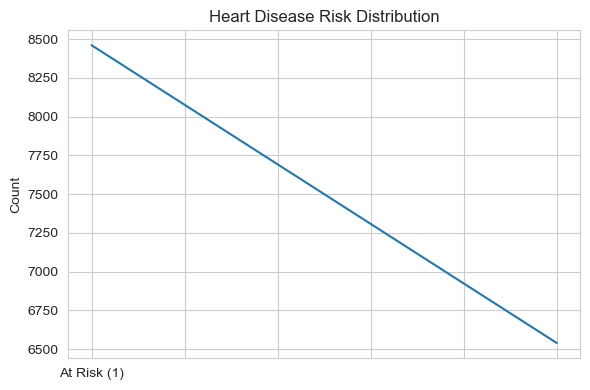

In [ ]:
print(df['Heart_Disease_Risk'].value_counts())
print(f'Positive rate: {df["Heart_Disease_Risk"].mean()}')

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(df['Heart_Disease_Risk'].value_counts())
ax.set_title('Heart Disease Risk Distribution')
ax.set_xticklabels(['No Risk (0)', 'At Risk (1)'], rotation=0)
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 2. Feature Distributions

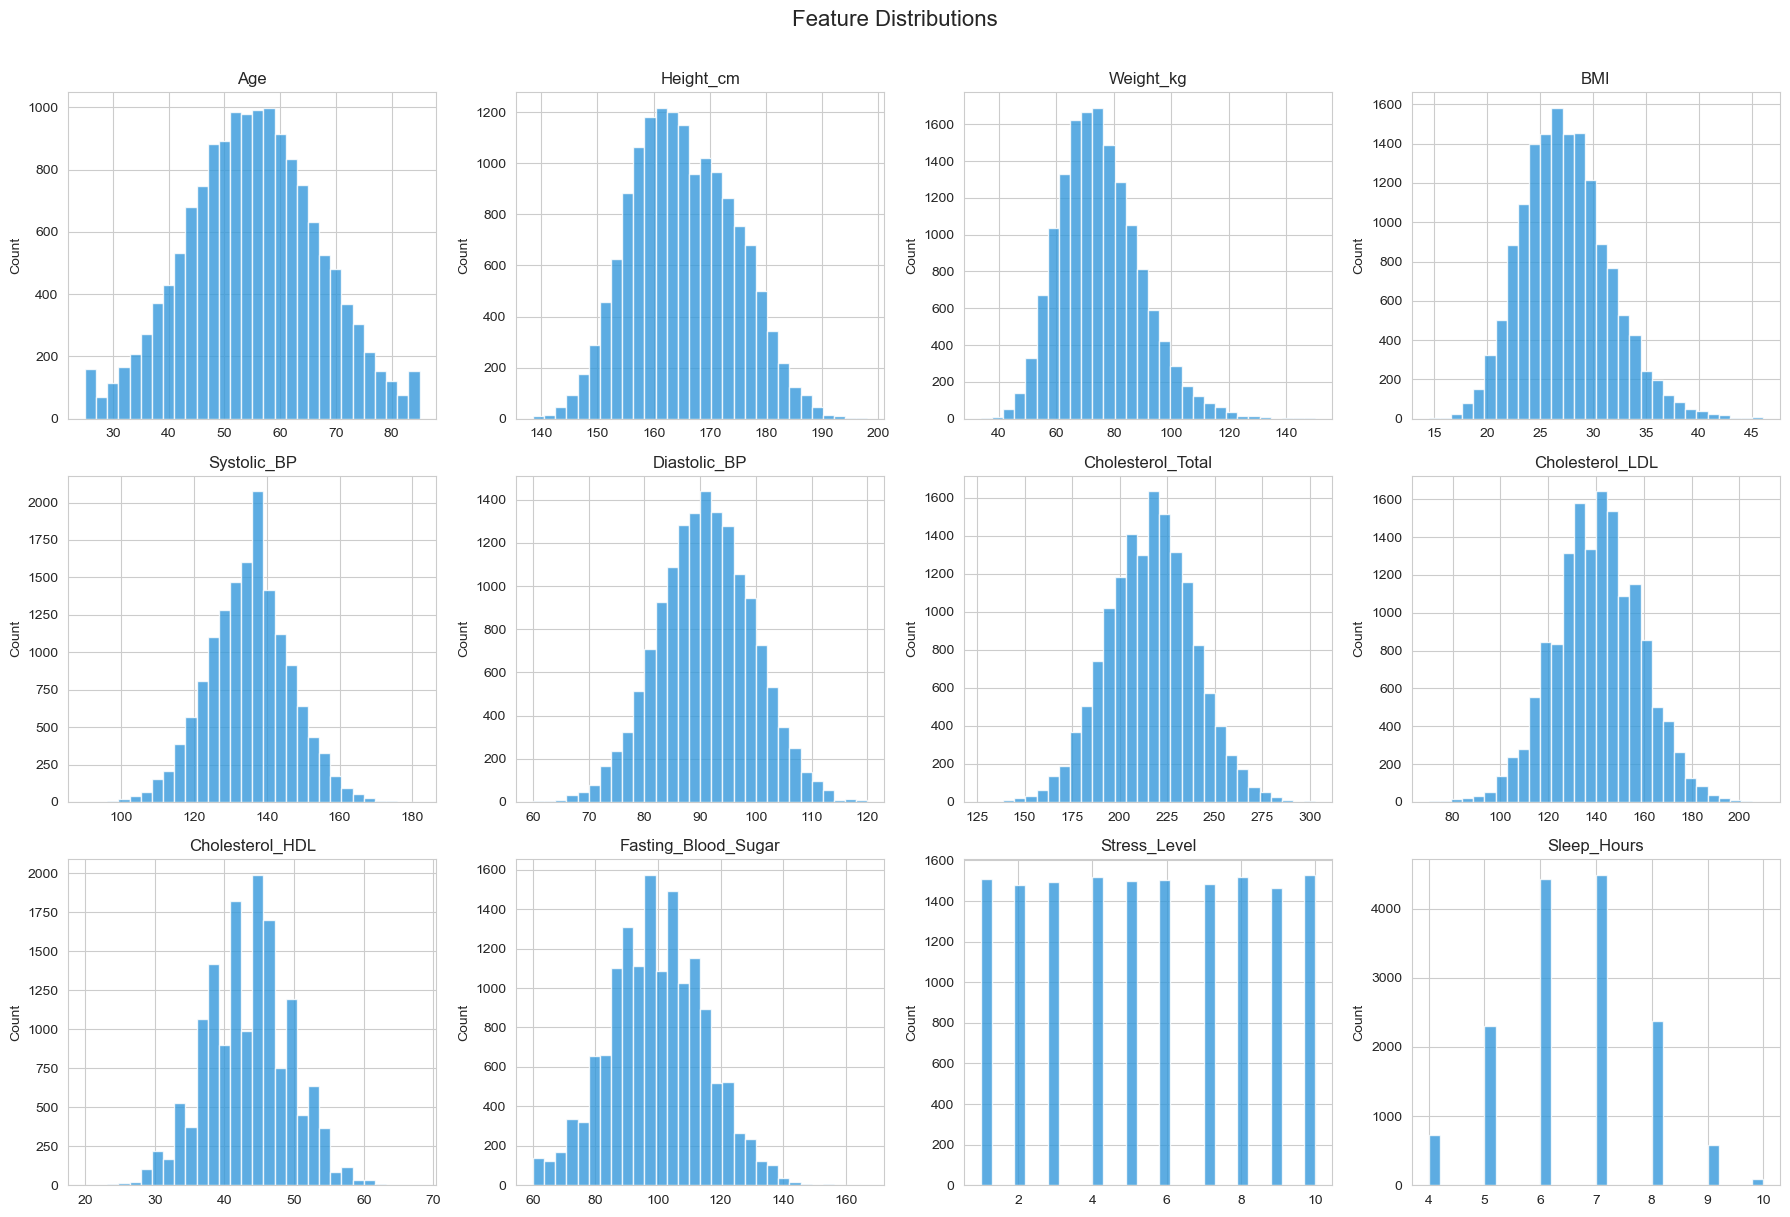

In [6]:
continuous_cols = ['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Systolic_BP', 'Diastolic_BP',
                   'Cholesterol_Total', 'Cholesterol_LDL', 'Cholesterol_HDL',
                   'Fasting_Blood_Sugar', 'Stress_Level', 'Sleep_Hours']

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
for i, col in enumerate(continuous_cols):
    ax = axes[i // 4, i % 4]
    df[col].hist(bins=30, ax=ax, color='#3498db', edgecolor='white', alpha=0.8)
    ax.set_title(col)
    ax.set_ylabel('Count')
plt.suptitle('Feature Distributions', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

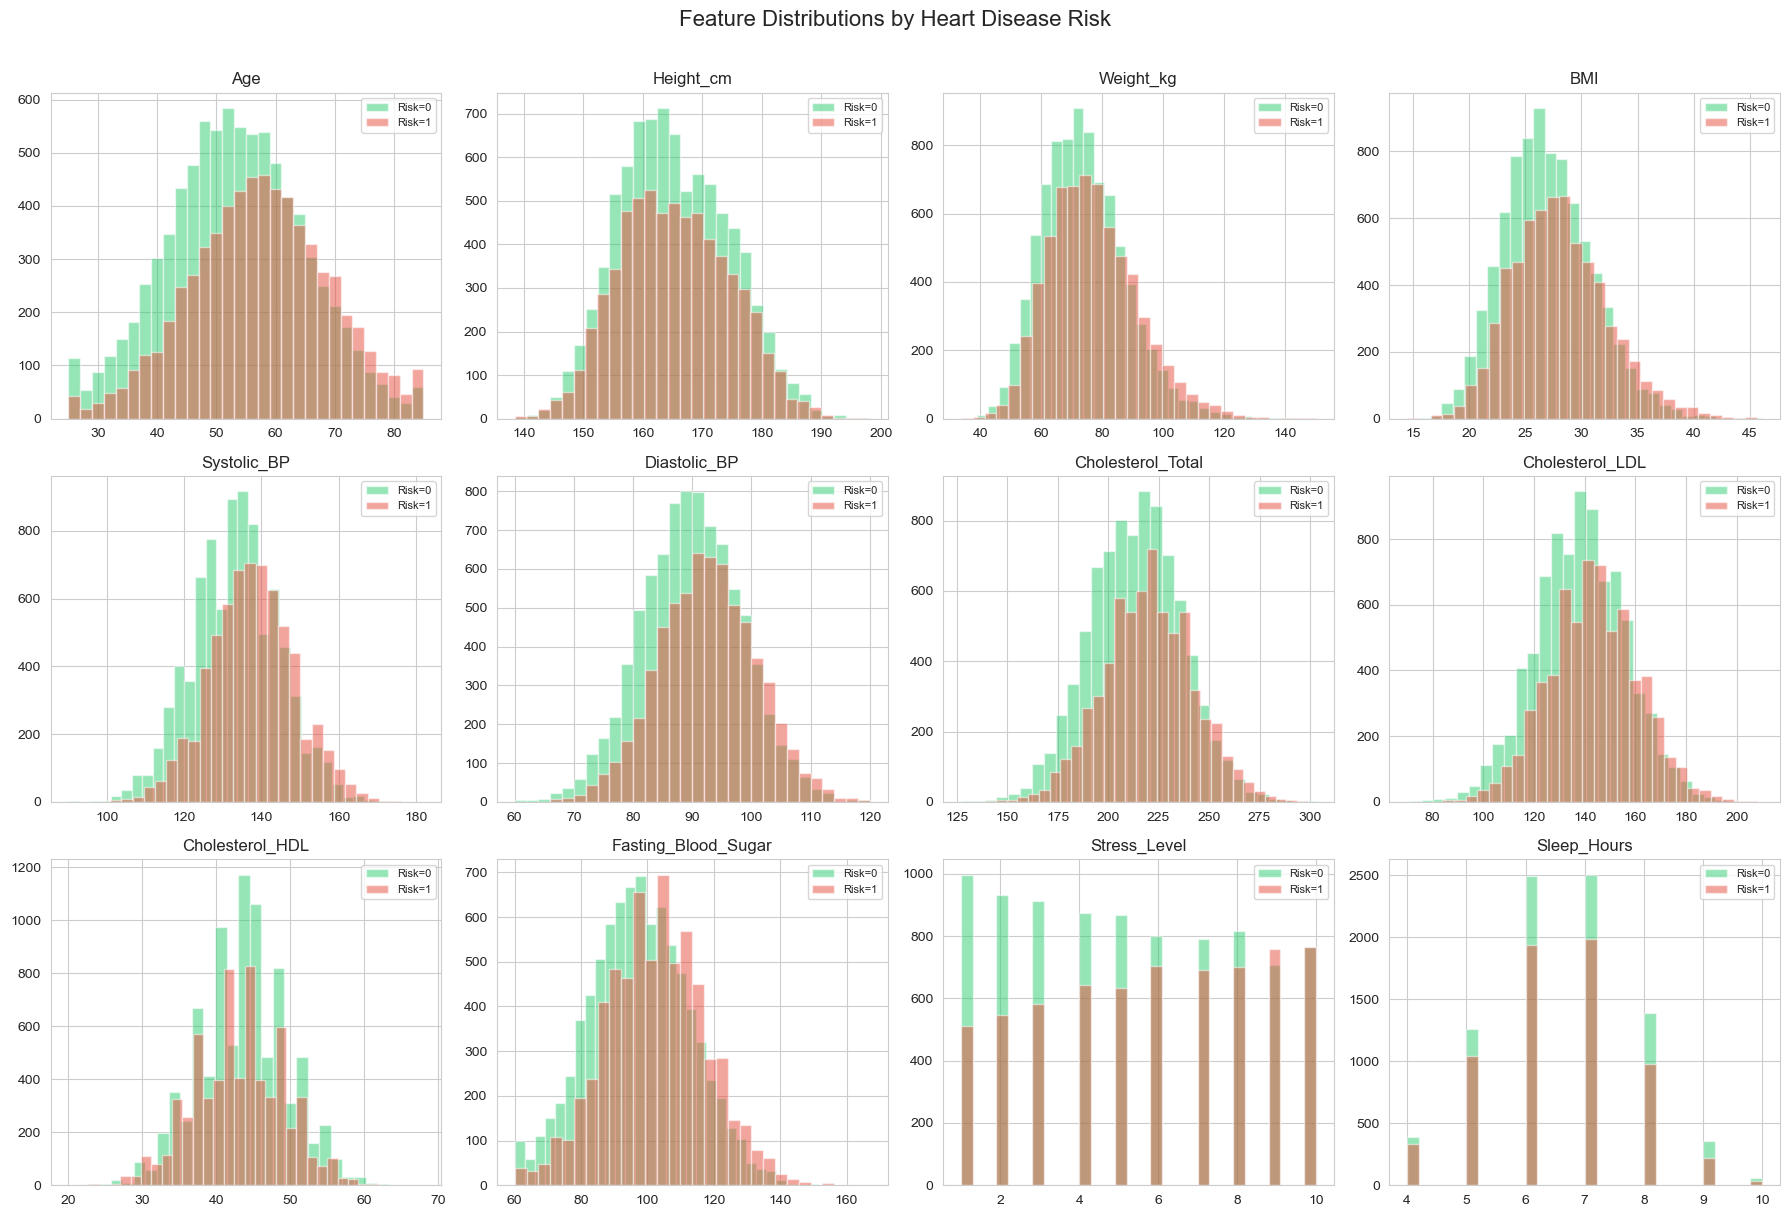

In [7]:
# Distributions split by target class
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
for i, col in enumerate(continuous_cols):
    ax = axes[i // 4, i % 4]
    for label, color in [(0, '#2ecc71'), (1, '#e74c3c')]:
        df[df['Heart_Disease_Risk'] == label][col].hist(
            bins=30, ax=ax, color=color, alpha=0.5,
            label=f'Risk={label}', edgecolor='white'
        )
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.suptitle('Feature Distributions by Heart Disease Risk', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

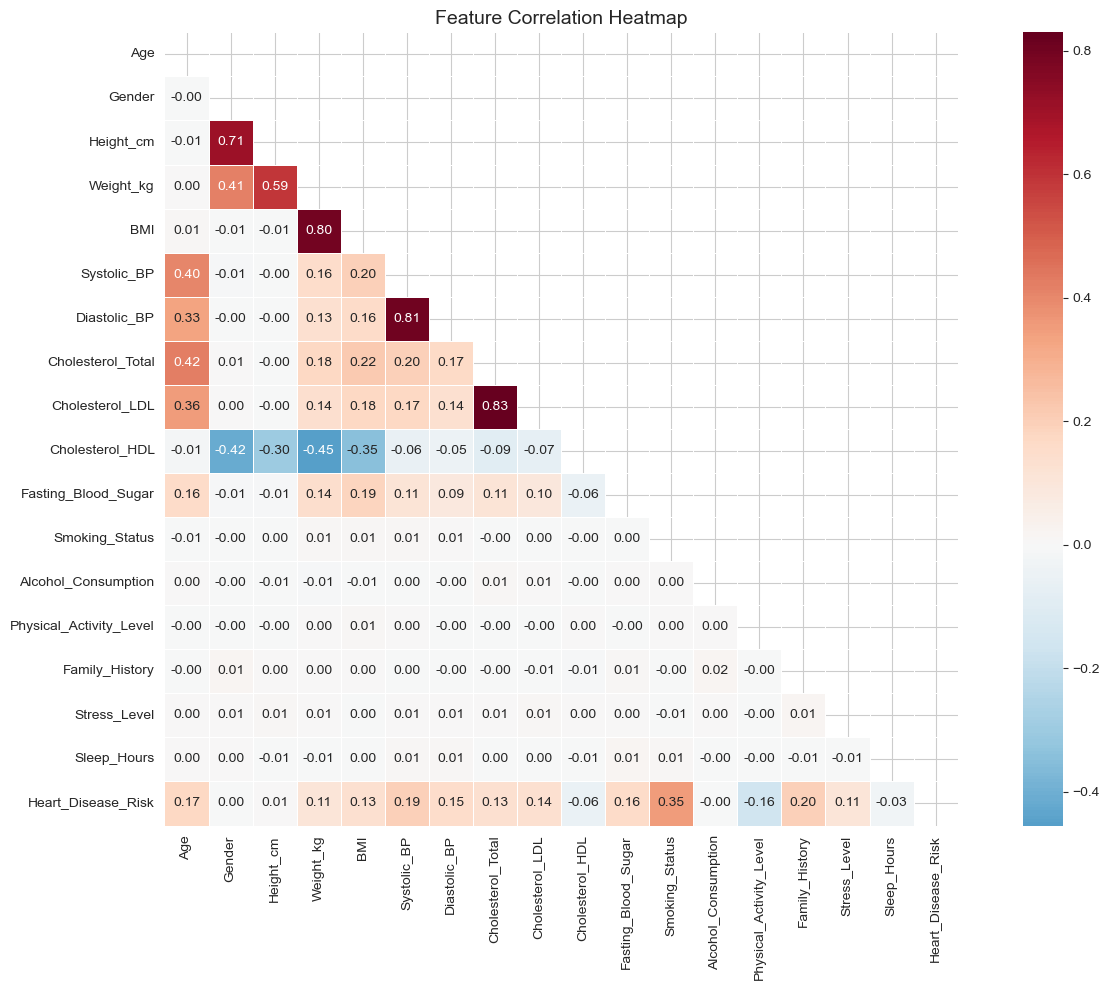

In [8]:
# Correlation heatmap
numeric_df = df.drop(columns=['Patient_ID'])
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Data Cleaning

In [9]:
# Drop Patient_ID (identifier, not a feature)
df_clean = df.drop(columns=['Patient_ID'])
print(f'Shape after dropping Patient_ID: {df_clean.shape}')

Shape after dropping Patient_ID: (15000, 18)


In [10]:
# Outlier check (IQR) — informational only, no removal
print('Outlier counts (IQR method):')
for col in df_clean.select_dtypes(include=[np.number]).columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df_clean[col] < Q1 - 1.5*IQR) | (df_clean[col] > Q3 + 1.5*IQR)).sum()
    if outliers > 0:
        print(f'  {col}: {outliers} ({outliers/len(df_clean):.1%})')
print('(No removal — synthetic data, outliers are realistic extreme values)')

Outlier counts (IQR method):
  Height_cm: 15 (0.1%)
  Weight_kg: 202 (1.3%)
  BMI: 176 (1.2%)
  Systolic_BP: 53 (0.4%)
  Diastolic_BP: 130 (0.9%)
  Cholesterol_Total: 121 (0.8%)
  Cholesterol_LDL: 113 (0.8%)
  Cholesterol_HDL: 67 (0.4%)
  Fasting_Blood_Sugar: 40 (0.3%)
  Family_History: 2243 (15.0%)
  Sleep_Hours: 1399 (9.3%)
(No removal — synthetic data, outliers are realistic extreme values)


## 4. Feature Engineering
All engineered features are **continuous** to maintain a smooth feature space for counterfactual optimization.

In [11]:
# Cholesterol ratios
df_clean['Cholesterol_Ratio'] = df_clean['Cholesterol_Total'] / df_clean['Cholesterol_HDL']
df_clean['LDL_HDL_Ratio'] = df_clean['Cholesterol_LDL'] / df_clean['Cholesterol_HDL']

# Blood pressure derived
df_clean['Pulse_Pressure'] = df_clean['Systolic_BP'] - df_clean['Diastolic_BP']
df_clean['MAP'] = df_clean['Diastolic_BP'] + (df_clean['Pulse_Pressure'] / 3)

# BMI × Age interaction
df_clean['BMI_Age'] = df_clean['BMI'] * df_clean['Age']

# Composite risk score (weighted normalized sum)
def minmax(s):
    return (s - s.min()) / (s.max() - s.min())

df_clean['Risk_Score'] = (
    0.15 * minmax(df_clean['Age']) +
    0.15 * minmax(df_clean['Systolic_BP']) +
    0.10 * minmax(df_clean['Diastolic_BP']) +
    0.10 * minmax(df_clean['Cholesterol_Total']) +
    0.10 * minmax(df_clean['Cholesterol_LDL']) +
    0.05 * (1 - minmax(df_clean['Cholesterol_HDL'])) +
    0.10 * df_clean['Smoking_Status'] / 2 +
    0.10 * df_clean['Family_History'] +
    0.05 * minmax(df_clean['Stress_Level']) +
    0.05 * (1 - minmax(df_clean['Sleep_Hours'])) +
    0.05 * minmax(df_clean['Fasting_Blood_Sugar'])
)

print(f'Shape after engineering: {df_clean.shape}')
print(f'New features: Cholesterol_Ratio, LDL_HDL_Ratio, Pulse_Pressure, MAP, BMI_Age, Risk_Score')
df_clean.head()

Shape after engineering: (15000, 24)
New features: Cholesterol_Ratio, LDL_HDL_Ratio, Pulse_Pressure, MAP, BMI_Age, Risk_Score


,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,...,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk,Cholesterol_Ratio,LDL_HDL_Ratio,Pulse_Pressure,MAP,BMI_Age,Risk_Score
0,60,0,146.9,51.3,23.8,140,89,217,151,52,...,0,1,8,0,4.173077,2.903846,51,106.000000,1428.0,0.370430
1,53,0,161.8,76.6,29.3,128,81,203,119,38,...,0,7,9,0,5.342105,3.131579,47,96.666667,1552.9,0.344223
2,62,1,174.7,92.4,30.3,141,100,173,124,45,...,0,1,7,1,3.844444,2.755556,41,113.666667,1878.6,0.370004
3,73,1,173.3,68.9,22.9,136,96,193,117,45,...,0,2,7,1,4.288889,2.600000,40,109.333333,1671.7,0.390398
4,52,1,178.6,79.8,25.0,122,80,236,153,41,...,0,2,6,0,5.756098,3.731707,42,94.000000,1300.0,0.350117


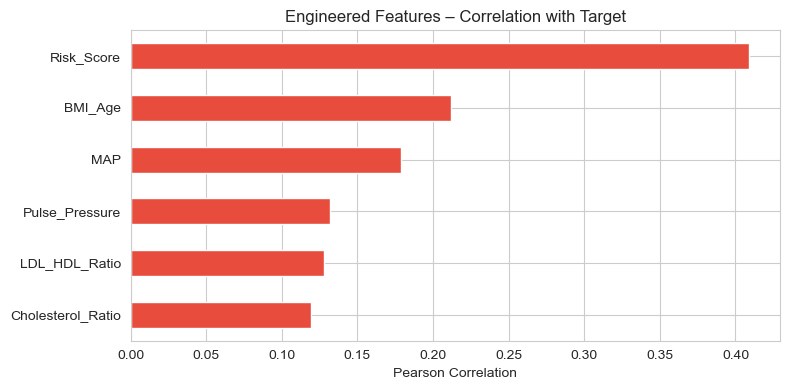

In [12]:
# Correlation of engineered features with target
new_features = ['Cholesterol_Ratio', 'LDL_HDL_Ratio', 'Pulse_Pressure', 'MAP', 'BMI_Age', 'Risk_Score']
target_corr = df_clean[new_features + ['Heart_Disease_Risk']].corr()['Heart_Disease_Risk'].drop('Heart_Disease_Risk')

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in target_corr.sort_values()]
target_corr.sort_values().plot(kind='barh', ax=ax, color=colors)
ax.set_title('Engineered Features – Correlation with Target')
ax.set_xlabel('Pearson Correlation')
ax.axvline(0, color='k', lw=0.5)
plt.tight_layout()
plt.show()

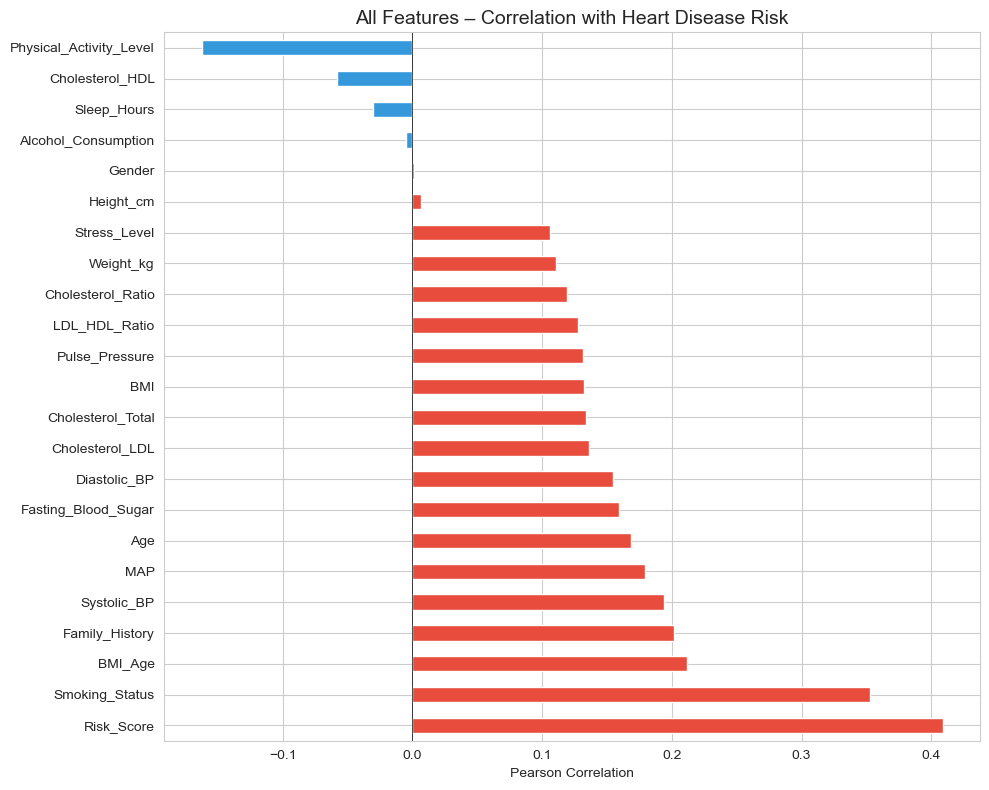

In [13]:
# Full correlation with target
full_corr = df_clean.corr()['Heart_Disease_Risk'].drop('Heart_Disease_Risk').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in full_corr]
full_corr.plot(kind='barh', ax=ax, color=colors)
ax.set_title('All Features – Correlation with Heart Disease Risk', fontsize=14)
ax.set_xlabel('Pearson Correlation')
ax.axvline(0, color='k', lw=0.5)
plt.tight_layout()
plt.show()

## 5. Save Processed Data

In [14]:
# Save to data/ folder
out_path = 'processed_data.csv'
df_clean.to_csv(out_path, index=False)
print(f'Saved: {out_path}  ({df_clean.shape[0]} rows × {df_clean.shape[1]} cols)')
print(f'Columns: {list(df_clean.columns)}')

Saved: processed_data.csv  (15000 rows × 24 cols)
Columns: ['Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Cholesterol_Total', 'Cholesterol_LDL', 'Cholesterol_HDL', 'Fasting_Blood_Sugar', 'Smoking_Status', 'Alcohol_Consumption', 'Physical_Activity_Level', 'Family_History', 'Stress_Level', 'Sleep_Hours', 'Heart_Disease_Risk', 'Cholesterol_Ratio', 'LDL_HDL_Ratio', 'Pulse_Pressure', 'MAP', 'BMI_Age', 'Risk_Score']


## Notes

**Key observations from EDA:**
- No missing values or duplicates in the dataset
- Target is reasonably balanced
- Engineered features (especially `Risk_Score`, `Cholesterol_Ratio`) show meaningful correlation with target
- All features kept continuous — no categorical binning — to preserve smooth gradients for counterfactual optimization

**Features used by downstream models:**
- Original: Age, Gender, Height_cm, Weight_kg, BMI, Systolic_BP, Diastolic_BP, Cholesterol_Total/LDL/HDL, Fasting_Blood_Sugar, Smoking_Status, Alcohol_Consumption, Physical_Activity_Level, Family_History, Stress_Level, Sleep_Hours
- Engineered: Cholesterol_Ratio, LDL_HDL_Ratio, Pulse_Pressure, MAP, BMI_Age, Risk_Score